## **Explainable AI (XAI) techniques**

In [17]:
# Import required libraries for model, tokenizer, and visualization
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel

In [18]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
def get_attention_scores(model, inputs):
    outputs = model(**inputs, output_attentions=True)
    return outputs.attentions  # list of tensors

def visualize_attention(attention_scores, tokens):
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=(8, 8))

    # Last layer attention: (batch_size, num_heads, seq_len, seq_len)
    attention_layer = attention_scores[-1]

    # First batch, first head
    attention_weights = attention_layer[0, 0].detach().numpy()

    sns.heatmap(attention_weights, xticklabels=tokens, yticklabels=tokens, cmap="viridis", ax=ax)
    plt.title("Attention Visualization")
    plt.show()

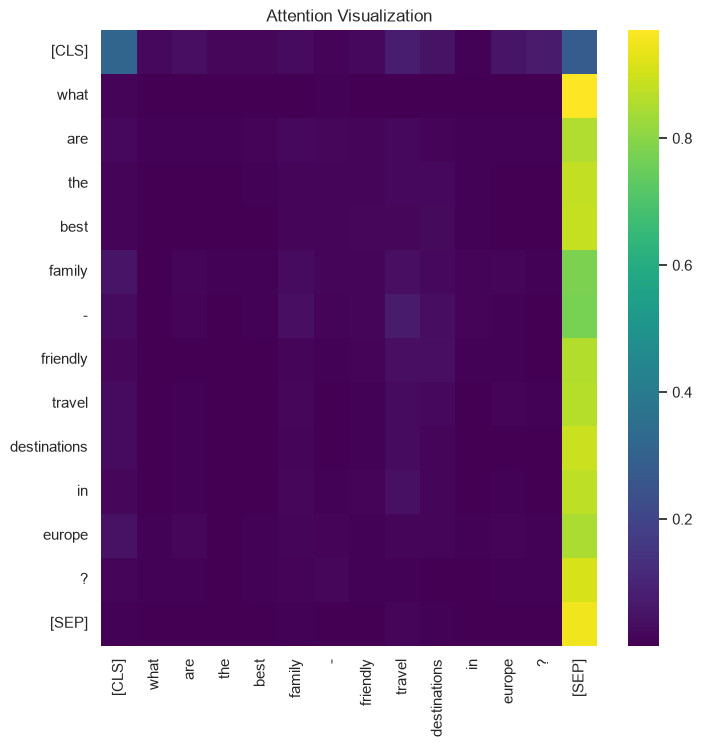

In [20]:
# Get attention scores from the model
attention_scores = get_attention_scores(model, inputs)

# Decode the input IDs to get human-readable tokens
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Visualize the attention scores for the tokens in the input
visualize_attention(attention_scores, tokens)

## **Saliency Maps**

In [21]:
# Import necessary library for saliency map visualization
from captum.attr import Saliency

In [24]:
# Load tokenizer and classification model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")
model.eval()  # set to evaluation mode

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [25]:
# Saliency Map Visualization function
def visualize_saliency(sentence):
    # Step 1: Tokenize input
    inputs = tokenizer(sentence, return_tensors='pt', truncation=True, padding=True)
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    # Step 2: Get embeddings with gradient tracking
    embeddings = model.get_input_embeddings()(input_ids).requires_grad_()

    # Step 3: Define forward function returning logits
    def forward_with_logits(embeddings):
        outputs = model(inputs_embeds=embeddings, attention_mask=attention_mask)
        return outputs.logits

    # Step 4: Initialize Saliency and compute scores
    saliency = Saliency(forward_with_logits)
    saliency_scores = saliency.attribute(embeddings, target=1)  # target class index

    # Step 5: Convert IDs back to tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Step 6: Aggregate scores across embedding dimensions
    saliency_scores = saliency_scores.sum(dim=2).squeeze()

    # Step 7: Visualize
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(tokens)), saliency_scores.detach().numpy(), tick_label=tokens, color='teal')
    plt.xticks(rotation=45)
    plt.title("Saliency Map")
    plt.show()

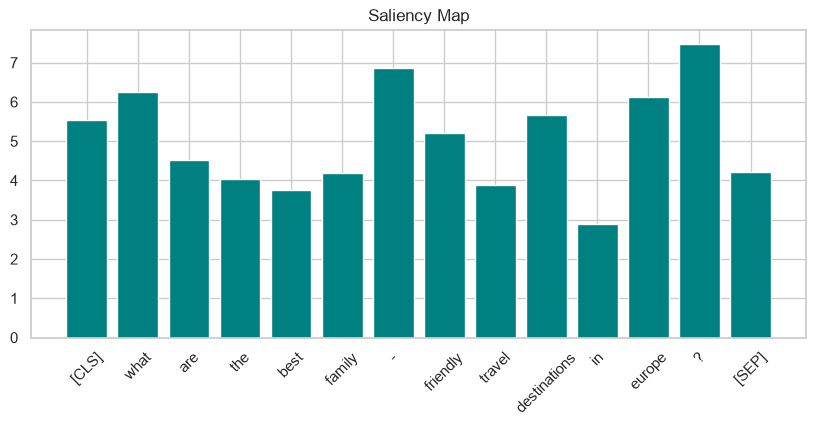

In [26]:
# Example input sentence
travel_query = "What are the best family-friendly travel destinations in Europe?"

# Example sentence to visualize saliency for
visualize_saliency(travel_query)

In [28]:
!uv pip install openai --quiet

In [29]:
import getpass
from openai import OpenAI
import os

api_key = getpass.getpass(prompt="Enter OpenAI API Key: ")
os.environ["OPENAI_API_KEY"] = api_key

In [30]:
# Function to generate an explanation using OpenAI
def generate_explanation_with_openai(text):
    # Initialize the OpenAI client with the API key stored in the environment variables
    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    # Use the OpenAI client to make a request for generating a completion (explanation)
    response = client.chat.completions.create(
        model="gpt-4o-mini",  # Specify the model to be used for generation
        messages=[  # Provide the context for the model
            {"role": "system", "content": "You are an explainability assistant."},  # System message setting the assistant's role
            {"role": "user", "content": f"Explain why '{text}' is important in the context of travel."}  # User query with the input text
        ]
    )

    # Extract the generated explanation from the response object
    explanation = response.choices[0].message.content

    # Return the explanation text
    return explanation

# Example usage: calling the function with a sample input
explanation = generate_explanation_with_openai(travel_query)

# Output the generated explanation
print(f"Explanation:\n{explanation}")

Explanation:
The question "What are the best family-friendly travel destinations in Europe?" is important in the context of travel for several reasons:

1. **Family-Centric Planning**: Families often seek travel destinations that cater to various age groups, providing activities and amenities suitable for children and adults alike. Identifying family-friendly destinations helps in planning trips that accommodate the needs and preferences of all family members.

2. **Safety and Comfort**: Family travel typically involves concerns around safety, comfort, and accessibility. Understanding which destinations offer safe environments, child-friendly infrastructures, and conveniences such as child care services or pediatric facilities is crucial for family travelers.

3. **Enrichment and Education**: Many family-friendly destinations in Europe offer educational opportunities that can enrich children's knowledge while making travel enjoyable. Historical sites, museums with interactive exhibits,